# Lithium-Ion Battery Remaining Useful Life (RUL) Prediction Framework (Version 1.0)

## End-to-End Machine Learning Pipeline, Comprehensive EDA, 10 Models Benchmarking, and Diagnostic Analytics Suite

This notebook implements the complete Version 1.0 workflow for lithium-ion battery Remaining Useful Life (RUL) prediction. The architecture includes rigorous exploratory data analysis, leak-free scikit-learn standard scaling pipelines, 5-fold cross-validation with `GridSearchCV` hyperparameter optimization across 10 diverse machine learning algorithms, GPU acceleration via NVIDIA CUDA, and an extensive diagnostic suite for project review.

## Environment Setup and Library Imports

In [56]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

# Publication style configuration
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

print("Environment configured successfully. Publication styling active.")

Environment configured successfully. Publication styling active.


## Module 1: Dataset Ingestion and Data Integrity Verification

In [57]:
df = pd.read_csv("standard_scaled_dataset.csv")
print(f"Dataset Dimensions: {df.shape[0]} samples, {df.shape[1]} columns")
display(df.head())

Dataset Dimensions: 14992 samples, 8 columns


,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,-0.052560,-0.021265,-2.647285,-2.999948,0.201022,0.057978,0.032341,1112
1,0.098135,-0.019743,3.761850,-2.926318,0.206570,0.058263,0.021627,1111
2,0.097669,-0.024052,3.795231,-2.893594,0.206570,0.058263,0.018539,1110
3,0.097410,-0.026418,3.806358,-2.885413,0.205780,0.058263,0.014771,1109
4,1.901905,2.053925,4.251437,-1.470097,0.203399,1.948155,1.805569,1107


In [58]:
desc = df.describe().T
desc['skewness'] = df.skew()
desc['kurtosis'] = df.kurtosis()
print("Statistical Characterization (Moments & Distribution Parameters):")
display(desc)

print("\nData Integrity Verification:")
print(f"Missing (Null) Values: {df.isnull().sum().sum()}")
print(f"Infinite Values:       {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")
print(f"Duplicate Records:     {df.duplicated().sum()}")

Statistical Characterization (Moments & Distribution Parameters):


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Discharge Time (s),14992.0,4.905361e-17,1.000000,-0.133541,-0.097130,-0.085051,-0.074078,29.869077,17.377992,381.846708
Decrement 3.6-3.4V (s),14992.0,4.549900e-17,1.000000,-0.102379,-0.081418,-0.072779,-0.061078,29.341588,16.122657,291.673189
Max. Voltage Dischar. (V),14992.0,-6.331944e-16,1.000000,-9.623896,-0.688939,-0.021320,0.713060,5.063706,-0.587394,11.648879
Min. Voltage Charg. (V),14992.0,-2.983976e-15,1.000000,-4.546160,-0.733806,-0.038419,0.697872,5.909180,0.275216,0.776527
Time at 4.15V (s),14992.0,4.265531e-18,1.000000,-0.415757,-0.209263,-0.085472,0.045136,27.341484,17.534114,388.464941
Time constant current (s),14992.0,1.753607e-17,1.000000,-0.216608,-0.112520,-0.061258,-0.012923,35.615801,25.630743,744.658320
Charging time (s),14992.0,7.109219e-17,1.000000,-0.383604,-0.080860,-0.062503,-0.045488,33.624655,23.448797,621.045504
RUL,14992.0,5.549416e+02,322.175186,0.000000,279.000000,551.000000,840.000000,1133.000000,0.003651,-1.205265



Data Integrity Verification:
Missing (Null) Values: 0
Infinite Values:       0
Duplicate Records:     0


## Module 2: Exploratory Data Analysis (EDA) Suite

The following sections conduct comprehensive statistical and exploratory investigations into target distributions, operational feature probability densities, outlier bounds, non-linear degradation dynamics, collinearity (VIF & rank correlation), PCA manifold projection, and multi-dimensional lifecycle signatures.

### Target Variable Distribution and Statistical Normality Analysis

Evaluates the continuous distribution of Remaining Useful Life (RUL) across 0 to 1,133 cycles using Kernel Density Estimation (KDE), a fitted Gaussian density curve ($N(\mu=554.9, \sigma=322.2)$), and a quantile boxplot highlighting median and interquartile ranges.

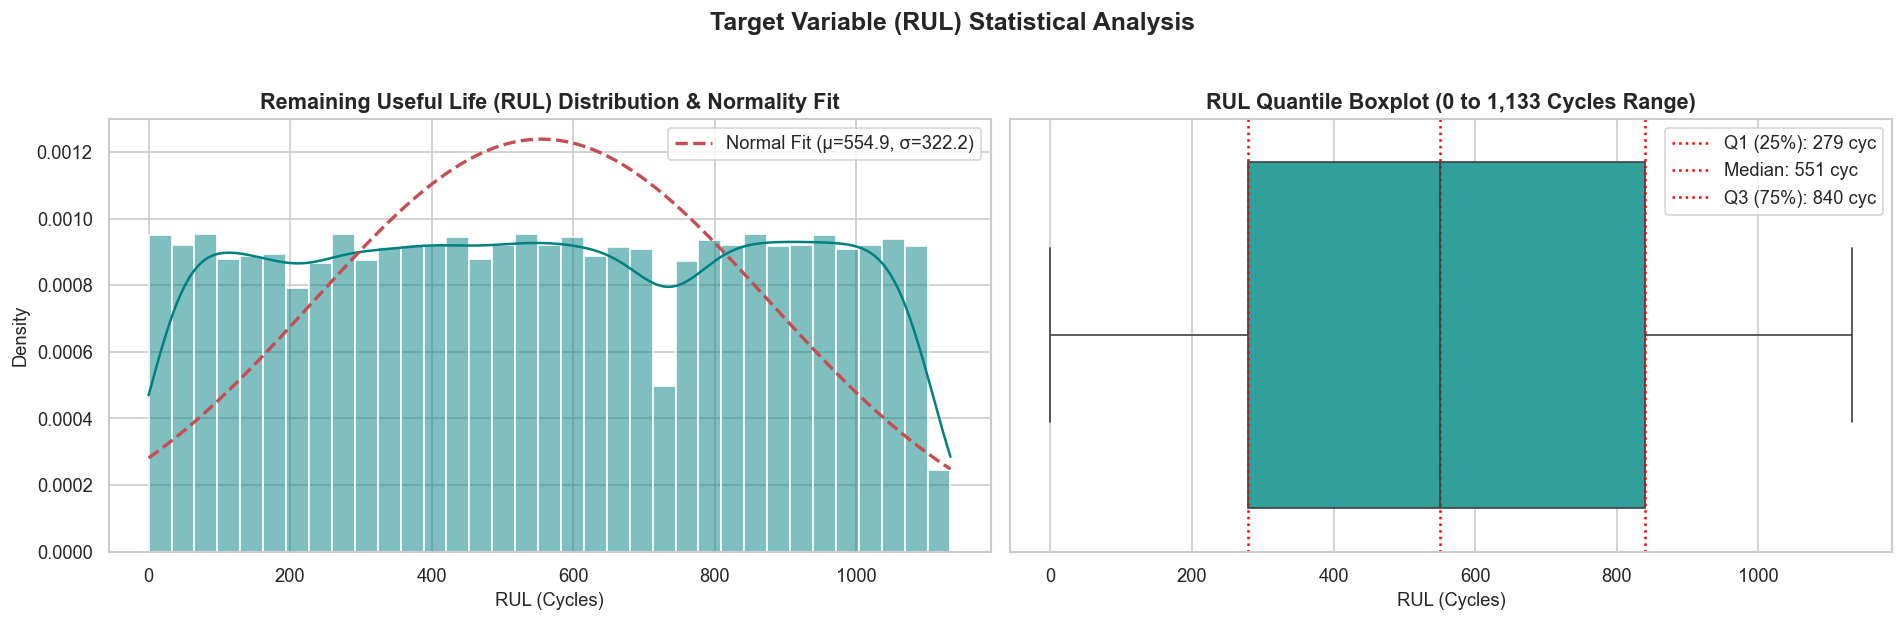

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Histogram + KDE + Fitted Normal Distribution
sns.histplot(df["RUL"], kde=True, bins=35, color="teal", stat="density", ax=axes[0])
mu_rul, std_rul = stats.norm.fit(df["RUL"])
x_line = np.linspace(df["RUL"].min(), df["RUL"].max(), 200)
axes[0].plot(x_line, stats.norm.pdf(x_line, mu_rul, std_rul), 'r--', linewidth=2, label=f'Normal Fit (μ={mu_rul:.1f}, σ={std_rul:.1f})')
axes[0].set_title("Remaining Useful Life (RUL) Distribution & Normality Fit", fontweight="bold")
axes[0].set_xlabel("RUL (Cycles)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Subplot 2: Boxplot with Quantile Annotations
sns.boxplot(x=df["RUL"], color="lightseagreen", ax=axes[1])
axes[1].set_title("RUL Quantile Boxplot (0 to 1,133 Cycles Range)", fontweight="bold")
axes[1].set_xlabel("RUL (Cycles)")
for q, label in zip([0.25, 0.50, 0.75], ["Q1 (25%)", "Median", "Q3 (75%)"]):
    val = df["RUL"].quantile(q)
    axes[1].axvline(val, color="red", linestyle=":", label=f"{label}: {val:.0f} cyc")
axes[1].legend(loc="upper right")

plt.suptitle("Target Variable (RUL) Statistical Analysis", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

### Interquartile Range and Outlier Spread Diagnostics

Standardized boxplot grid identifying the interquartile range (IQR), median values, and extreme tails across voltage cutoffs and charging phase dwell durations.

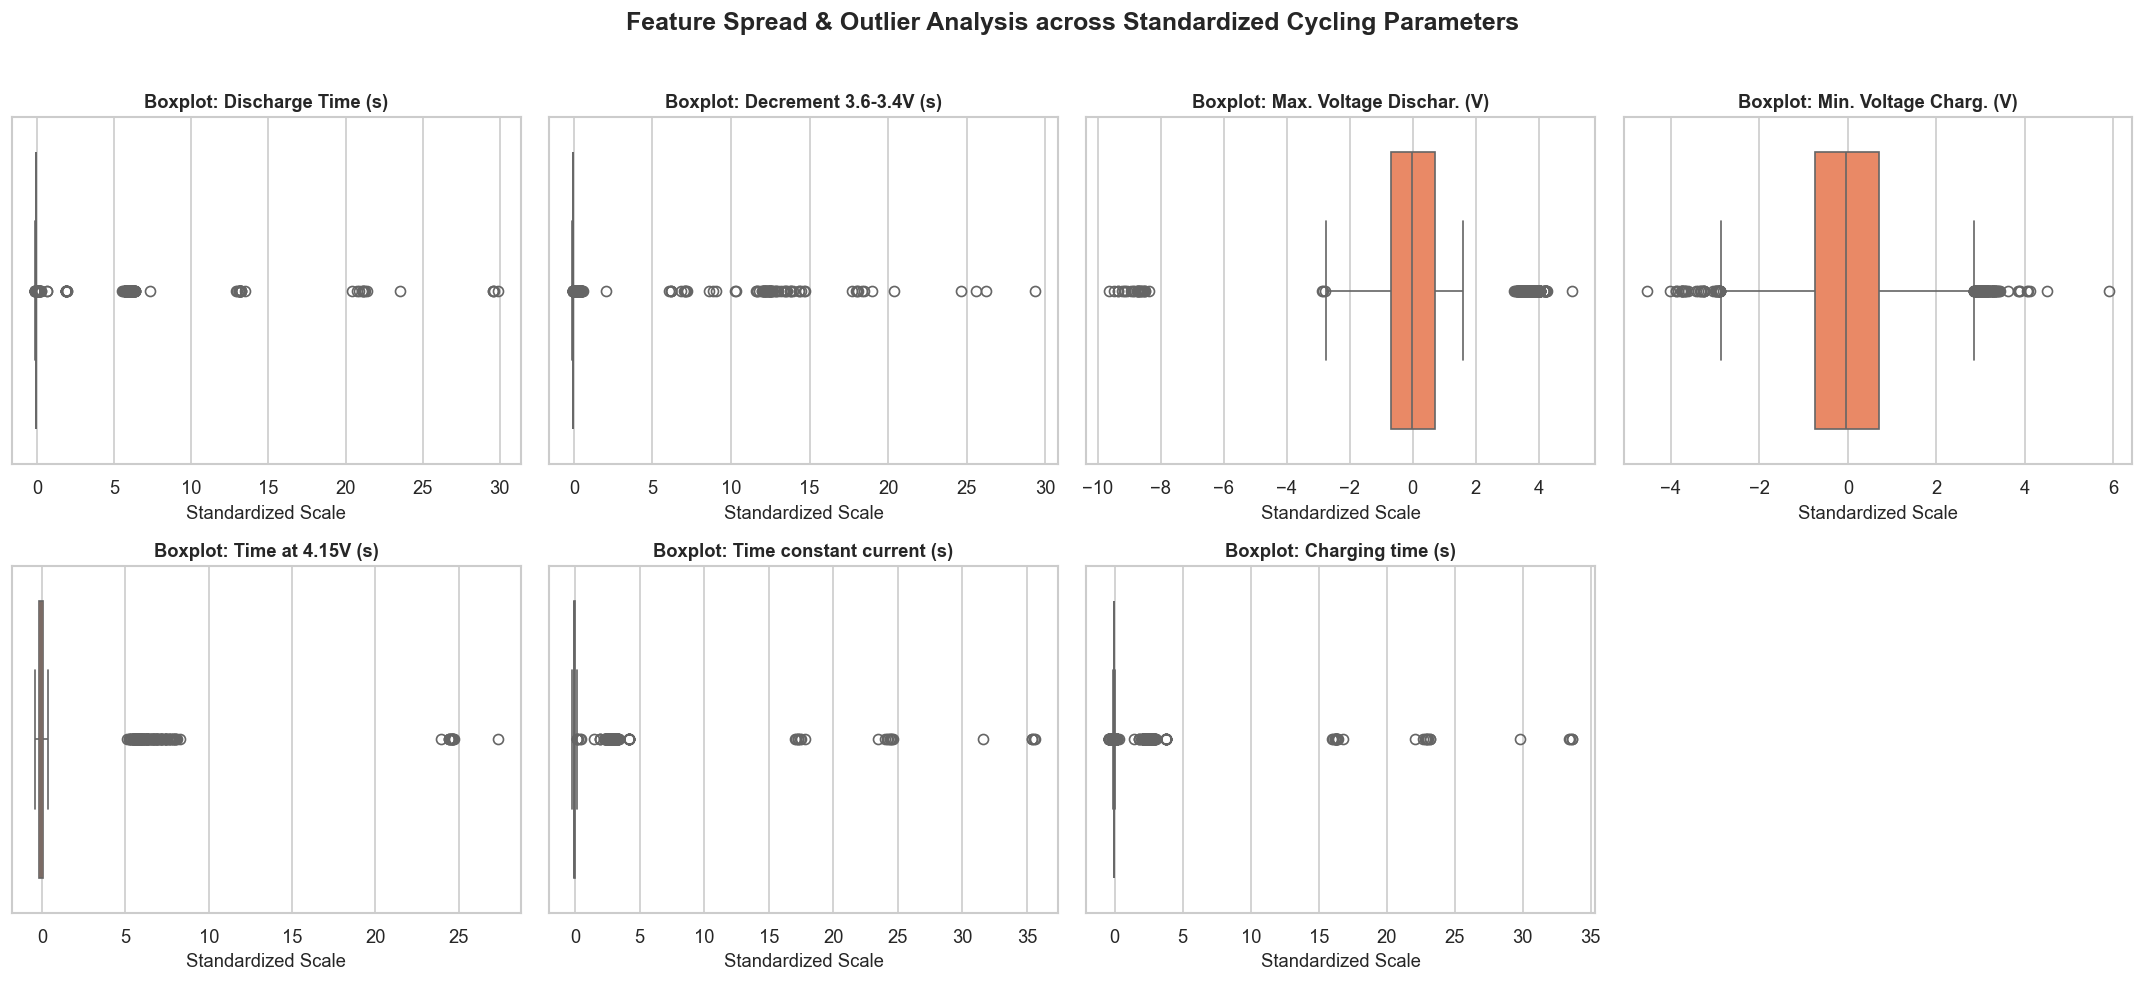

In [60]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x=df[col], color="coral", ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Standardized Scale")

fig.delaxes(axes[7])

plt.suptitle("Feature Spread & Outlier Analysis across Standardized Cycling Parameters", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Comparative Linear (Pearson) and Monotonic Rank (Spearman) Correlation Analysis

Contrasts linear correlation coefficients ($r$) against monotonic rank correlations ($
ho$) to identify non-linear feature interactions and rank monotonic trends across charging phase telemetry.

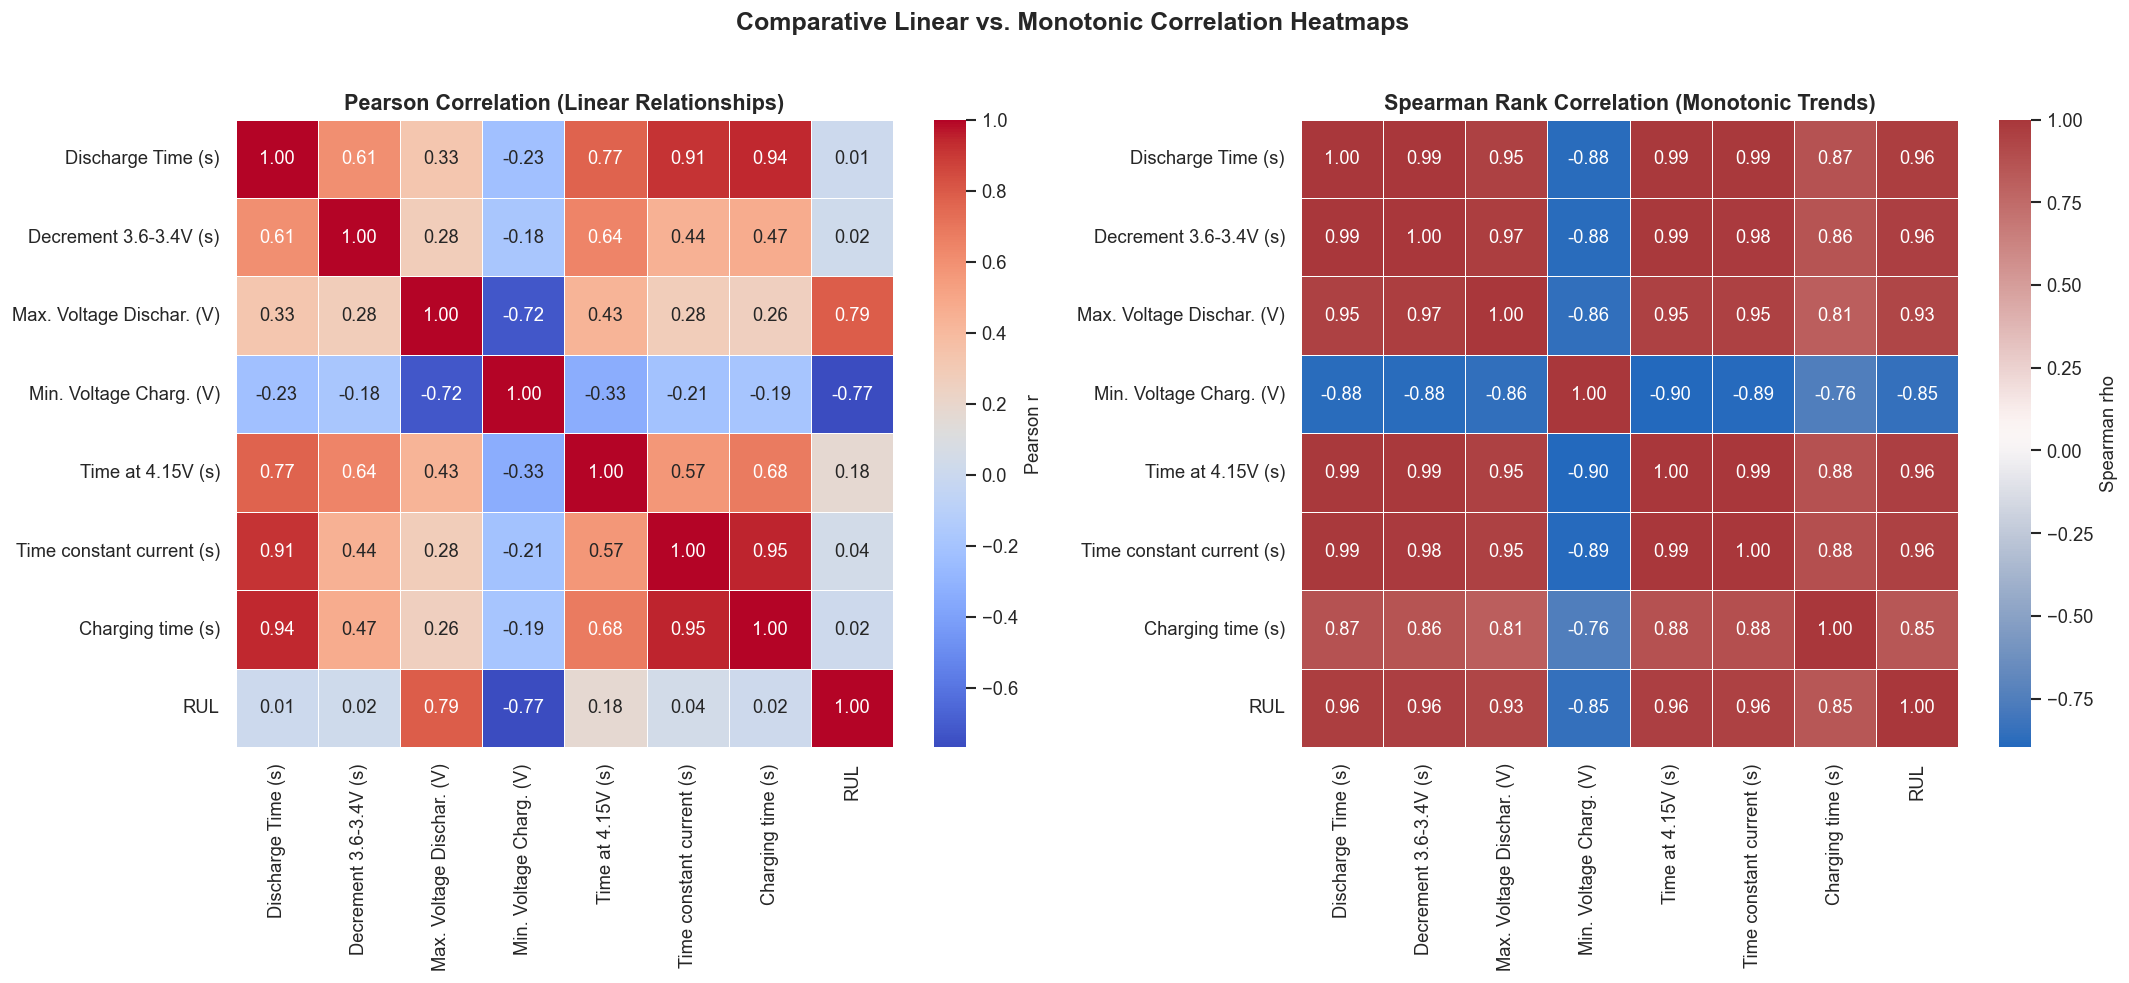

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Pearson Correlation
pearson_corr = df.corr(method="pearson")
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Pearson r'})
axes[0].set_title("Pearson Correlation (Linear Relationships)", fontsize=13, fontweight="bold")

# Spearman Rank Correlation
spearman_corr = df.corr(method="spearman")
sns.heatmap(spearman_corr, annot=True, cmap="vlag", fmt=".2f", linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Spearman rho'})
axes[1].set_title("Spearman Rank Correlation (Monotonic Trends)", fontsize=13, fontweight="bold")

plt.suptitle("Comparative Linear vs. Monotonic Correlation Heatmaps", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Principal Component Analysis (PCA) 2D Degradation Manifold Projection

Performs unsupervised dimensionality reduction across all 7 standardized features, projecting the degradation manifold into 2D space colored by continuous RUL, alongside a cumulative variance scree plot.

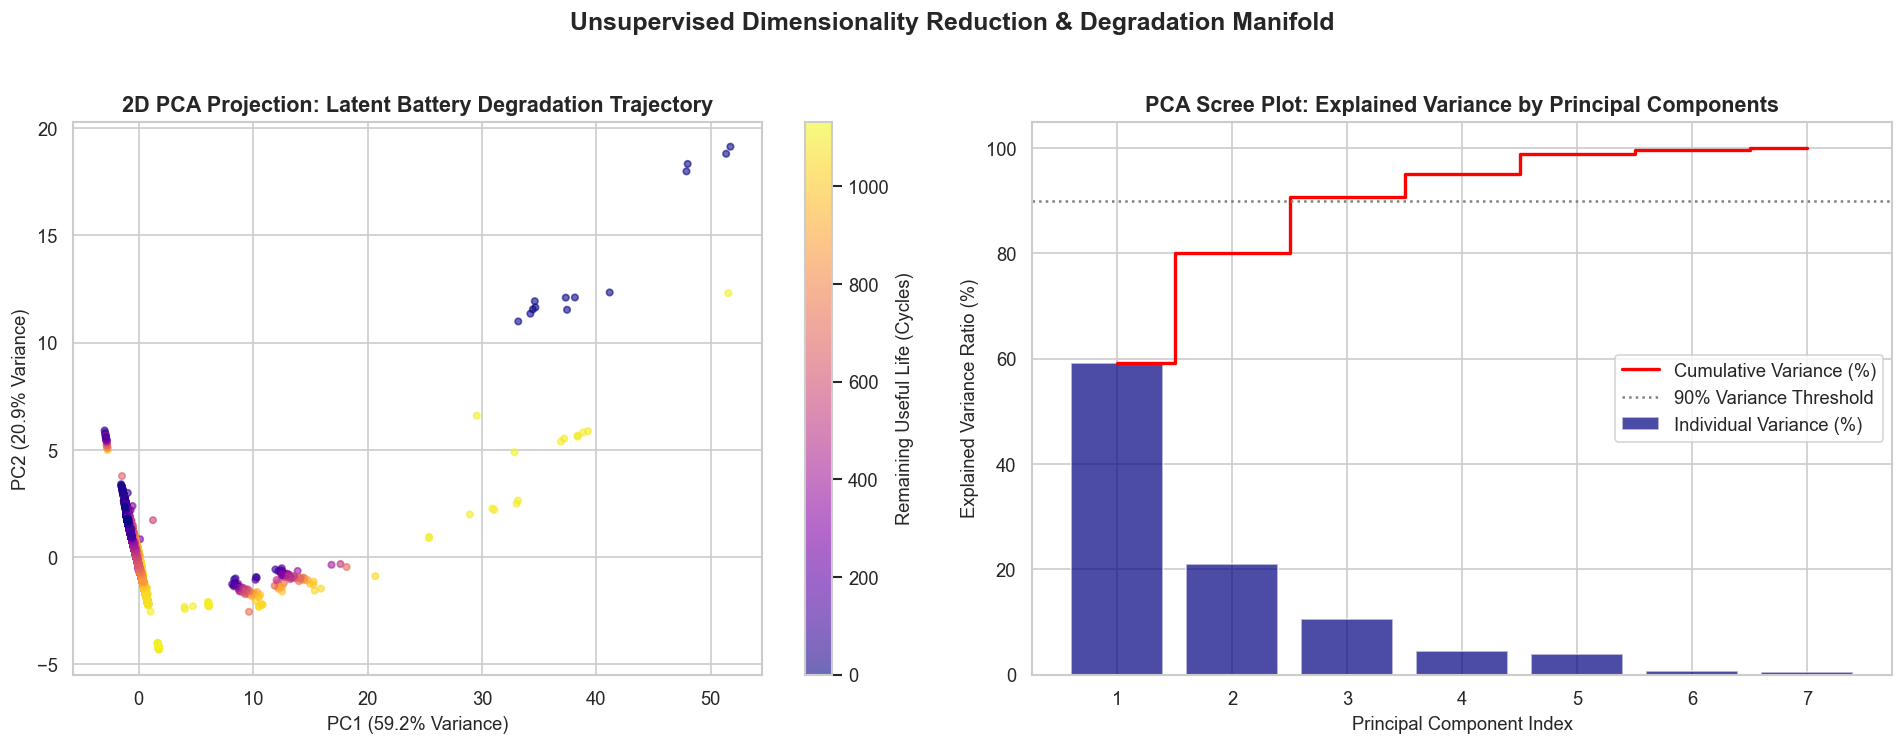

In [62]:
pca = PCA(n_components=7)
X_pca = pca.fit_transform(df[features])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: 2D Projection colored by RUL
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df["RUL"], cmap="plasma", alpha=0.6, s=15)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label("Remaining Useful Life (Cycles)", fontsize=11)
axes[0].set_title("2D PCA Projection: Latent Battery Degradation Trajectory", fontsize=13, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")

# Subplot 2: Scree Plot (Explained Variance Ratio)
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].bar(range(1, 8), pca.explained_variance_ratio_ * 100, alpha=0.7, color="navy", label="Individual Variance (%)")
axes[1].step(range(1, 8), cum_var, where="mid", color="red", linewidth=2, label="Cumulative Variance (%)")
axes[1].axhline(90, color="gray", linestyle=":", label="90% Variance Threshold")
axes[1].set_title("PCA Scree Plot: Explained Variance by Principal Components", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Principal Component Index")
axes[1].set_ylabel("Explained Variance Ratio (%)")
axes[1].legend(loc="center right")

plt.suptitle("Unsupervised Dimensionality Reduction & Degradation Manifold", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## Module 3: Train-Test Partitioning and 5-Fold Cross-Validation Setup

In [64]:
X = df.drop(columns=["RUL"])
y = df["RUL"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Training Samples: {X_train.shape[0]} (80%)")
print(f"Testing Samples:  {X_test.shape[0]} (20%)")

cv = KFold(n_splits=5, shuffle=True, random_state=42)

Training Samples: 11993 (80%)
Testing Samples:  2999 (20%)


## Module 4: Definition of 10 Machine Learning Models and Hyperparameter Grids

Defines 10 regression algorithms across bagging ensembles, gradient boosting, histogram-based boosting, adaptive boosting, instance-based learning, decision trees, and regularized linear baselines.

In [65]:
models_config = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 15],
            "model__min_samples_split": [2, 5]
        }
    },
    "Extra Trees": {
        "model": ExtraTreesRegressor(random_state=42, n_jobs=-1),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 15],
            "model__min_samples_split": [2, 5]
        }
    },
    "XGBoost (GPU)": {
        "model": XGBRegressor(objective="reg:squarederror", tree_method="hist", device="cuda", random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 5]
        }
    },
    "LightGBM": {
        "model": LGBMRegressor(random_state=42, verbosity=-1, n_jobs=-1),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__num_leaves": [15, 31]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 5]
        }
    },
    "Hist Gradient Boosting": {
        "model": HistGradientBoostingRegressor(random_state=42),
        "params": {
            "model__max_iter": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_leaf_nodes": [15, 31]
        }
    },
    "AdaBoost": {
        "model": AdaBoostRegressor(random_state=42),
        "params": {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.05, 0.1, 0.5]
        }
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsRegressor(n_jobs=-1),
        "params": {
            "model__n_neighbors": [3, 5, 7],
            "model__weights": ["uniform", "distance"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "model__max_depth": [10, 15, 20, None],
            "model__min_samples_split": [2, 5]
        }
    },
    "Ridge Regression": {
        "model": Ridge(),
        "params": {
            "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
        }
    }
}

print(f"Total Models Defined: {len(models_config)}")

Total Models Defined: 10


## Module 5: Baseline Training and 5-Fold GridSearchCV Hyperparameter Optimization

In [66]:
baseline_records = []
optimized_records = []
optimized_models = {}
optimized_test_preds = {}
grid_objects = {}

print("Training all 10 models (Baseline + 5-Fold GridSearchCV)...")

for name, cfg in models_config.items():
    print(f"-> Processing: {name}")
    pipe = Pipeline([("scaler", StandardScaler()), ("model", cfg["model"])])
    
    # Baseline Fit
    t0 = time.time()
    pipe.fit(X_train, y_train)
    tr_pred = pipe.predict(X_train)
    te_pred = pipe.predict(X_test)
    fit_time = round(time.time() - t0, 3)
    
    baseline_records.append({
        "Model": name,
        "Train MAE": round(mean_absolute_error(y_train, tr_pred), 4),
        "Test MAE": round(mean_absolute_error(y_test, te_pred), 4),
        "Train RMSE": round(np.sqrt(mean_squared_error(y_train, tr_pred)), 4),
        "Test RMSE": round(np.sqrt(mean_squared_error(y_test, te_pred)), 4),
        "Train R2": round(r2_score(y_train, tr_pred), 4),
        "Test R2": round(r2_score(y_test, te_pred), 4),
        "Fit Time (s)": fit_time
    })
    
    # 5-Fold GridSearchCV
    t1 = time.time()
    grid = GridSearchCV(pipe, cfg["params"], cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1 if name != "XGBoost (GPU)" else 1)
    grid.fit(X_train, y_train)
    tune_time = round(time.time() - t1, 3)
    
    best_pipe = grid.best_estimator_
    optimized_models[name] = best_pipe
    grid_objects[name] = grid
    
    opt_tr_pred = best_pipe.predict(X_train)
    opt_te_pred = best_pipe.predict(X_test)
    optimized_test_preds[name] = opt_te_pred
    
    optimized_records.append({
        "Model": name,
        "Best Parameters": str(grid.best_params_),
        "Best CV MAE": round(-grid.best_score_, 4),
        "Train MAE": round(mean_absolute_error(y_train, opt_tr_pred), 4),
        "Test MAE": round(mean_absolute_error(y_test, opt_te_pred), 4),
        "Train RMSE": round(np.sqrt(mean_squared_error(y_train, opt_tr_pred)), 4),
        "Test RMSE": round(np.sqrt(mean_squared_error(y_test, opt_te_pred)), 4),
        "Train R2": round(r2_score(y_train, opt_tr_pred), 4),
        "Test R2": round(r2_score(y_test, opt_te_pred), 4),
        "Tune Time (s)": tune_time
    })

baseline_results_df = pd.DataFrame(baseline_records)
optimized_results_df = pd.DataFrame(optimized_records)
print("\nBenchmark Results Summary:")
display(optimized_results_df.sort_values(by=["Test R2", "Test MAE"], ascending=[False, True]))

Training all 10 models (Baseline + 5-Fold GridSearchCV)...
-> Processing: Random Forest
-> Processing: Extra Trees
-> Processing: XGBoost (GPU)
-> Processing: LightGBM
-> Processing: Gradient Boosting
-> Processing: Hist Gradient Boosting
-> Processing: AdaBoost
-> Processing: K-Nearest Neighbors
-> Processing: Decision Tree
-> Processing: Ridge Regression

Benchmark Results Summary:


,Model,Best Parameters,Best CV MAE,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Tune Time (s)
1,Extra Trees,"{'model__max_depth': None, 'model__min_samples...",9.0991,0.0062,7.7124,0.0951,17.1383,1.0000,0.9971,9.434
0,Random Forest,"{'model__max_depth': None, 'model__min_samples...",10.8278,3.6062,9.4752,7.8045,21.1858,0.9994,0.9956,29.147
7,K-Nearest Neighbors,"{'model__n_neighbors': 3, 'model__weights': 'd...",13.1037,0.0026,11.3031,0.0616,26.8637,1.0000,0.9929,0.213
5,Hist Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_iter...",16.9568,13.8699,16.7832,21.4292,26.8505,0.9956,0.9929,2.006
4,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",18.5645,14.1621,17.9389,19.3183,26.9766,0.9964,0.9929,22.041
2,XGBoost (GPU),"{'model__learning_rate': 0.1, 'model__max_dept...",18.8530,15.0162,18.0052,21.3417,26.9789,0.9956,0.9929,11.726
3,LightGBM,"{'model__learning_rate': 0.1, 'model__n_estima...",16.5085,12.8228,16.0533,19.3459,27.6019,0.9964,0.9925,7.821
8,Decision Tree,"{'model__max_depth': None, 'model__min_samples...",12.2955,0.0061,10.5529,0.0951,29.9444,1.0000,0.9912,0.418
6,AdaBoost,"{'model__learning_rate': 0.5, 'model__n_estima...",54.9418,53.8349,54.2384,66.3086,66.8102,0.9578,0.9562,5.068
9,Ridge Regression,{'model__alpha': 0.01},92.5098,92.2897,92.2592,143.3108,150.9380,0.8031,0.7762,0.077


## Module 6: Model Diagnostics and Digital Twin Analytics Suite

### Operational Voltage Signatures Across Battery Lifecycle

Scatter plots showing how maximum discharge voltage and minimum charge voltage transition across battery aging cycles.

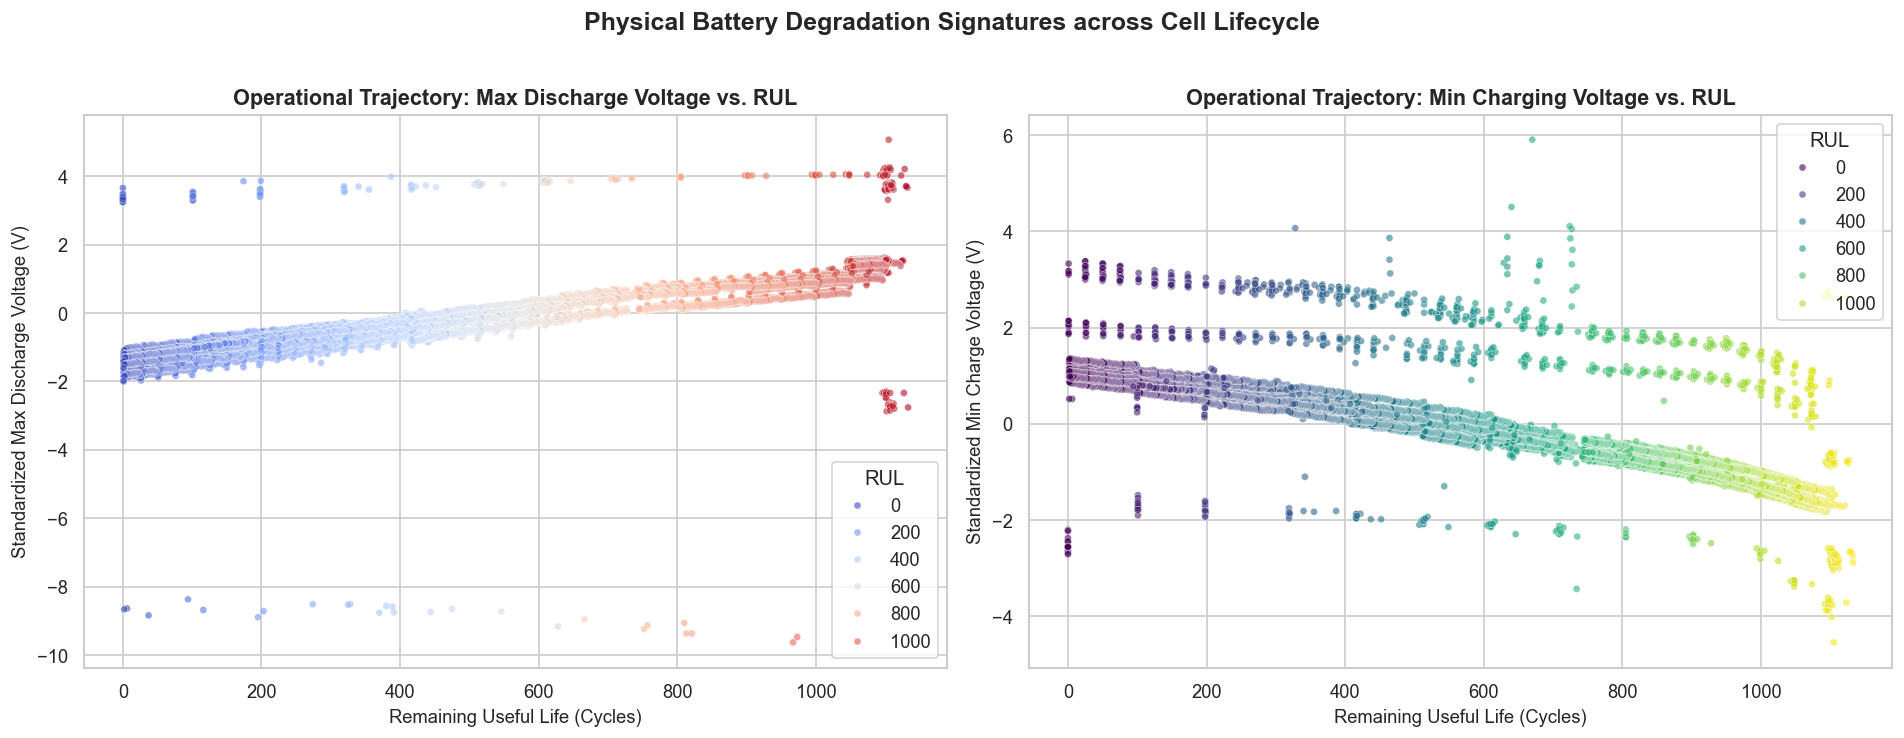

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x="RUL", y="Max. Voltage Dischar. (V)", hue="RUL", palette="coolwarm", alpha=0.6, s=18, ax=axes[0])
axes[0].set_title("Operational Trajectory: Max Discharge Voltage vs. RUL", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Remaining Useful Life (Cycles)")
axes[0].set_ylabel("Standardized Max Discharge Voltage (V)")

sns.scatterplot(data=df, x="RUL", y="Min. Voltage Charg. (V)", hue="RUL", palette="viridis", alpha=0.6, s=18, ax=axes[1])
axes[1].set_title("Operational Trajectory: Min Charging Voltage vs. RUL", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Remaining Useful Life (Cycles)")
axes[1].set_ylabel("Standardized Min Charge Voltage (V)")

plt.suptitle("Physical Battery Degradation Signatures across Cell Lifecycle", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Hierarchical Feature Clustermap

Applies hierarchical clustering to illustrate multi-variable groupings and correlation clusters among battery operational features.

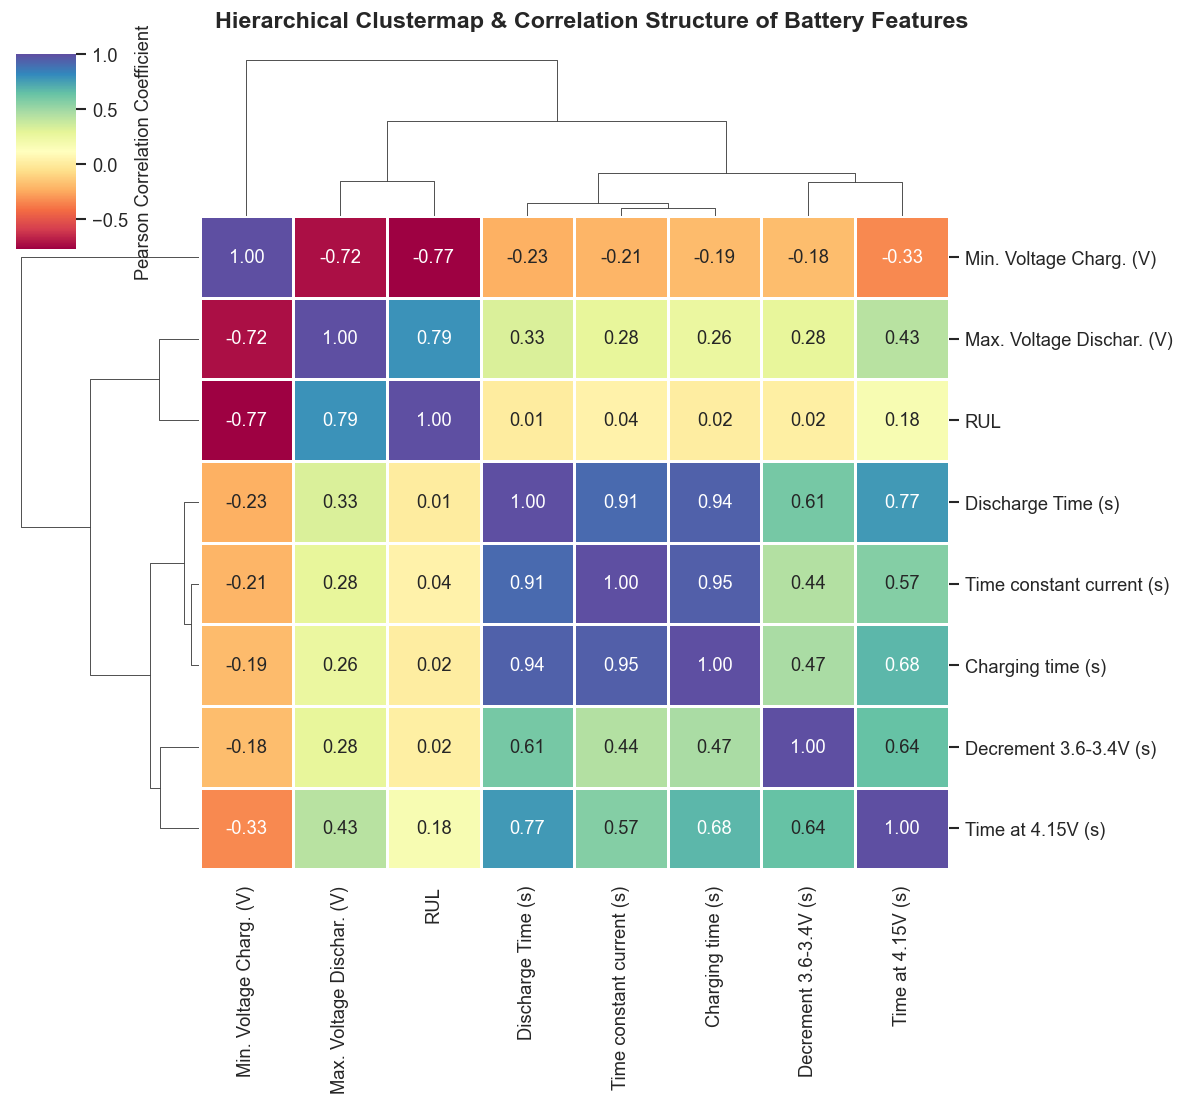

In [68]:
corr = df.corr()
clustermap = sns.clustermap(corr, annot=True, fmt=".2f", cmap="Spectral", figsize=(10, 9), linewidths=0.75, cbar_kws={'label': 'Pearson Correlation Coefficient'})
clustermap.fig.suptitle("Hierarchical Clustermap & Correlation Structure of Battery Features", fontsize=14, fontweight="bold", y=1.02)
plt.show()

### Degradation Feature Dynamics Stratified by Battery Aging Stages

Violin plots demonstrating distribution shifts across Early Life ($>750$ cyc), Mid Life ($300-750$ cyc), and Near End-of-Life ($<300$ cyc) battery stages.

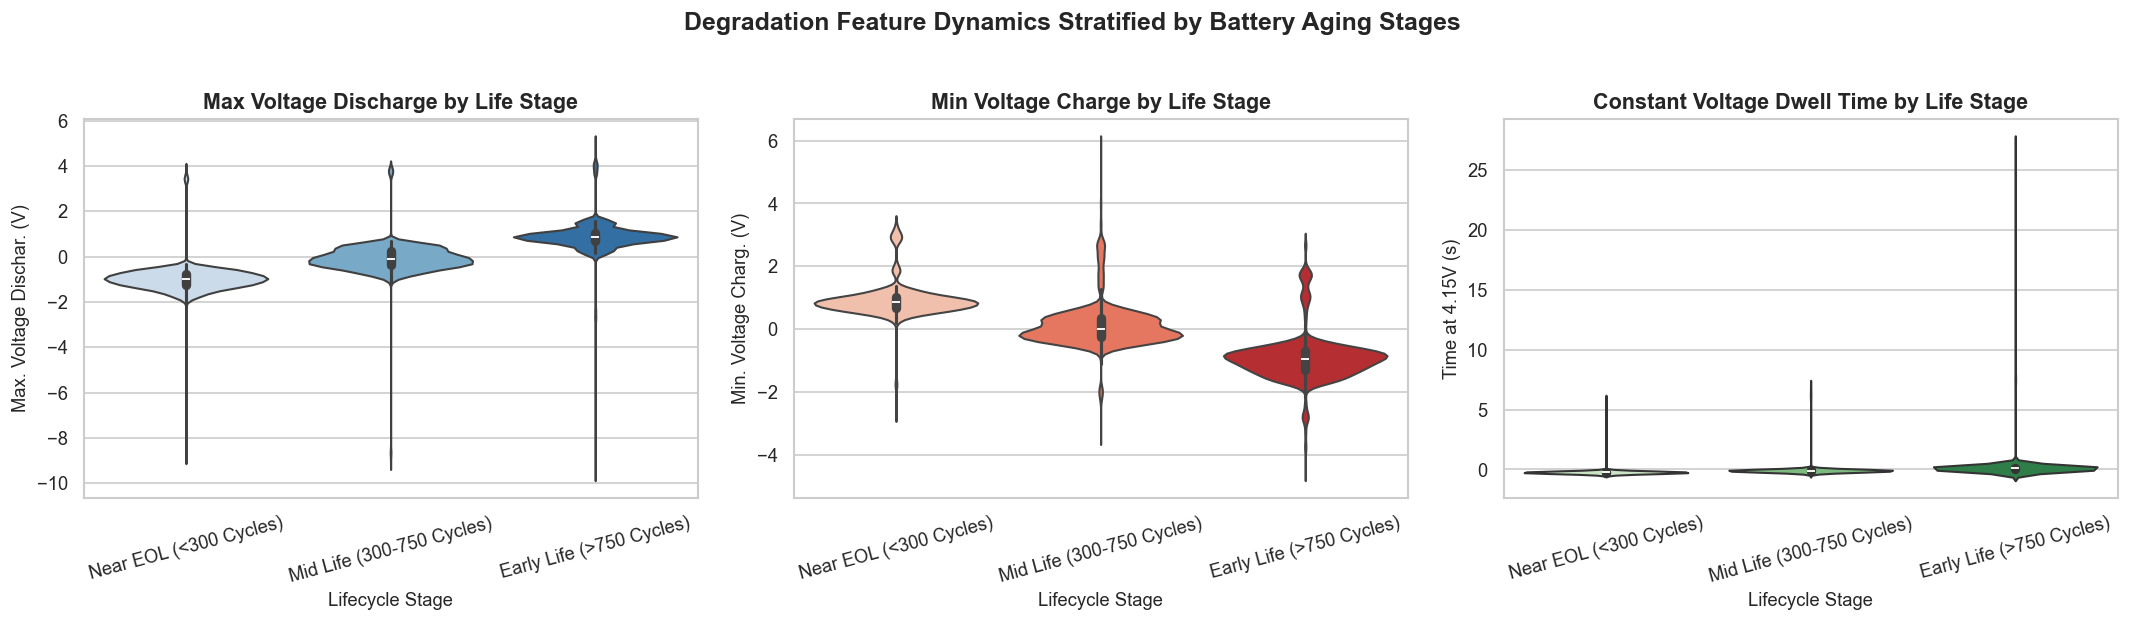

In [69]:
df_stage = df.copy()
df_stage["Lifecycle Stage"] = pd.cut(
    df_stage["RUL"], 
    bins=[-1, 300, 750, 1200], 
    labels=["Near EOL (<300 Cycles)", "Mid Life (300-750 Cycles)", "Early Life (>750 Cycles)"]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.violinplot(data=df_stage, x="Lifecycle Stage", y="Max. Voltage Dischar. (V)", palette="Blues", ax=axes[0])
axes[0].set_title("Max Voltage Discharge by Life Stage", fontweight="bold")

sns.violinplot(data=df_stage, x="Lifecycle Stage", y="Min. Voltage Charg. (V)", palette="Reds", ax=axes[1])
axes[1].set_title("Min Voltage Charge by Life Stage", fontweight="bold")

sns.violinplot(data=df_stage, x="Lifecycle Stage", y="Time at 4.15V (s)", palette="Greens", ax=axes[2])
axes[2].set_title("Constant Voltage Dwell Time by Life Stage", fontweight="bold")

for ax in axes:
    ax.tick_params(axis='x', rotation=15)
plt.suptitle("Degradation Feature Dynamics Stratified by Battery Aging Stages", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

### Comprehensive Multi-Metric Benchmark Comparison Matrix

4-panel bar chart matrix comparing Test MAE, Test RMSE, Test $R^2$, and Baseline vs. Tuned performance improvements across all 10 models side-by-side.

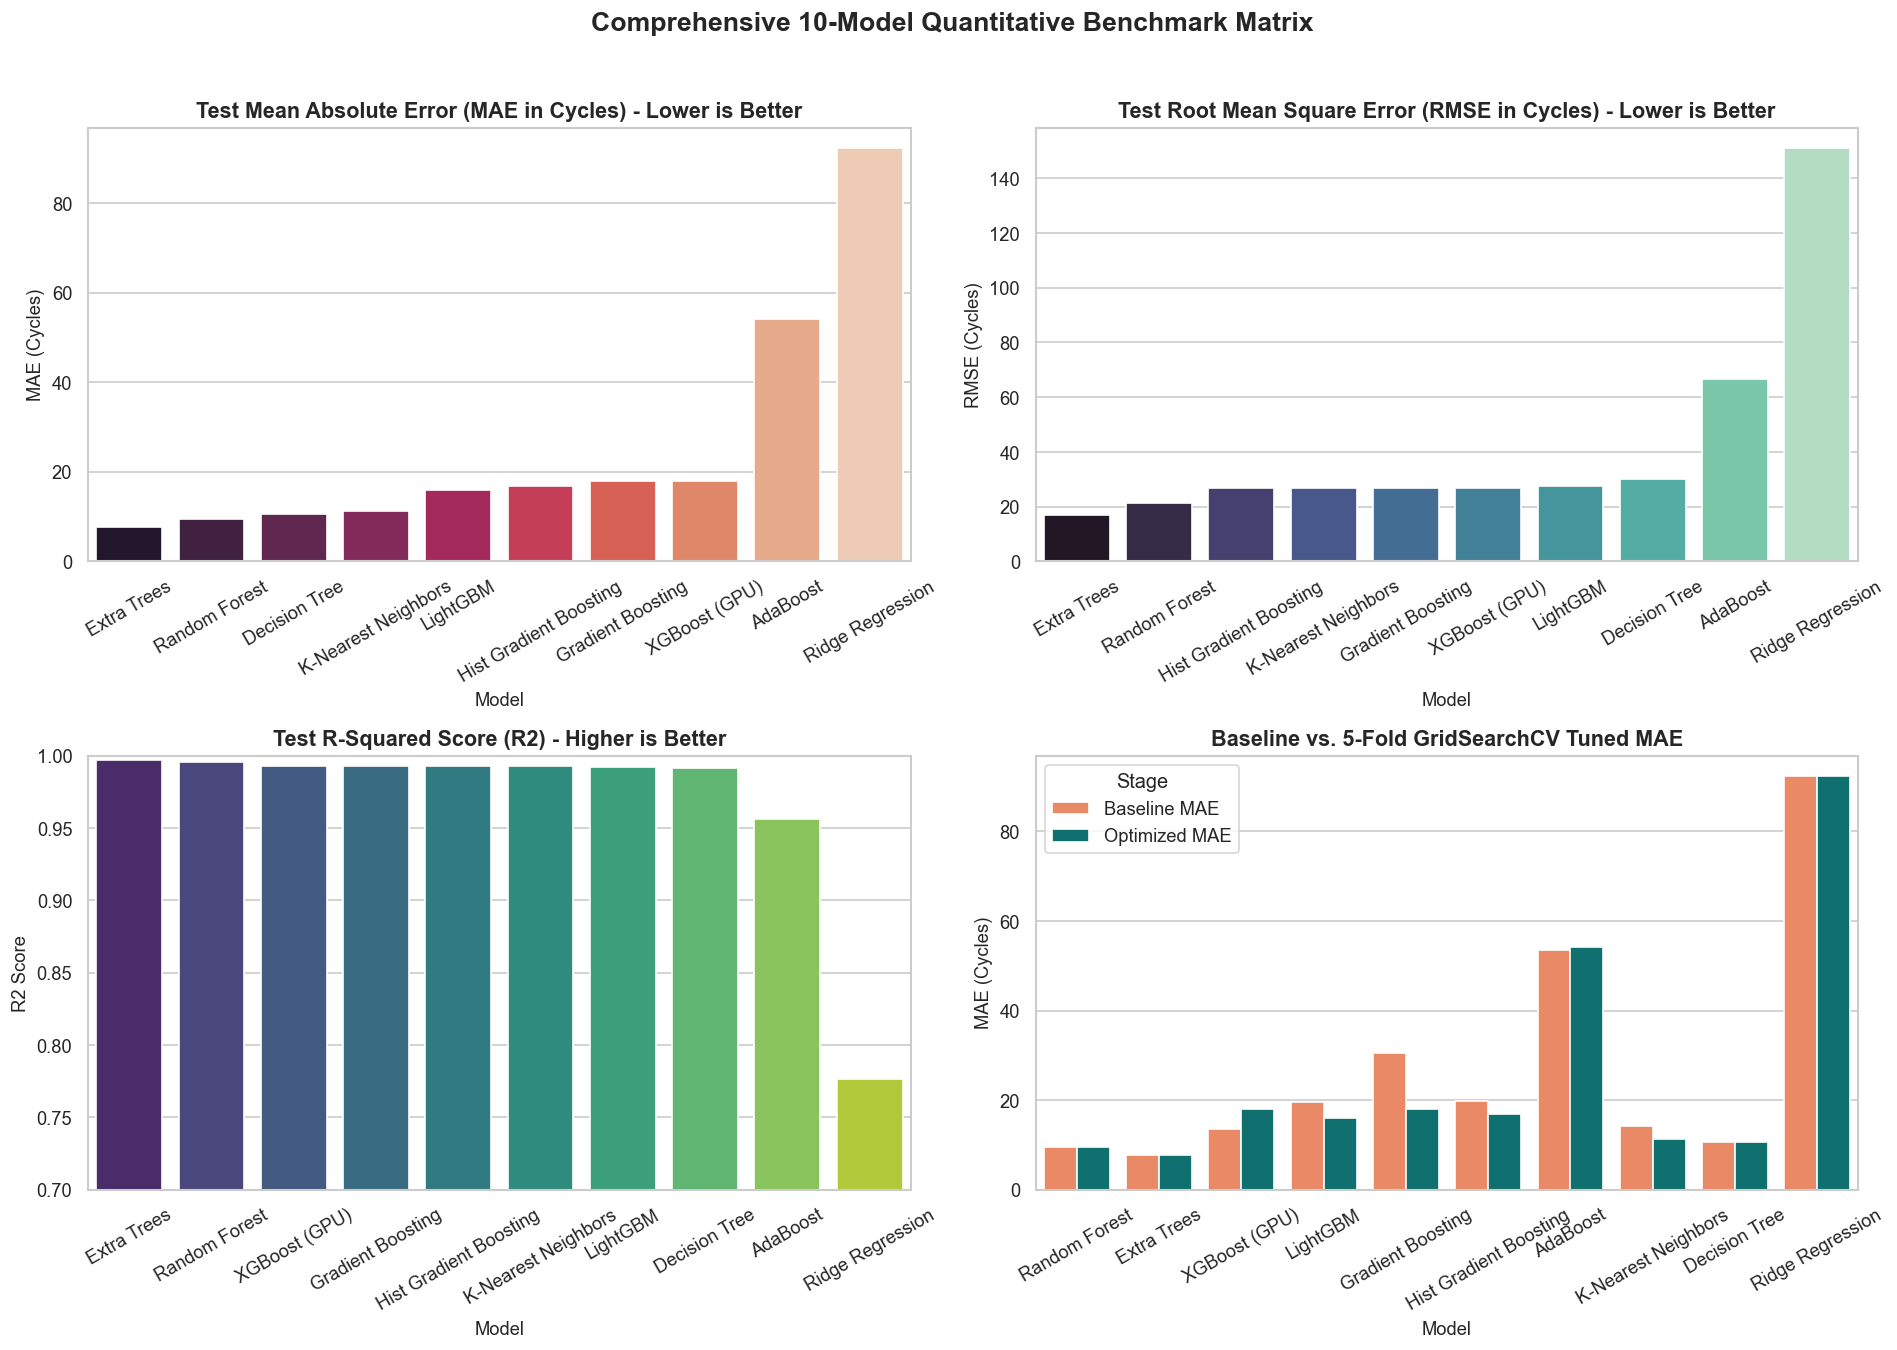

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

order_mae = optimized_results_df.sort_values(by="Test MAE")
sns.barplot(data=order_mae, x="Model", y="Test MAE", palette="rocket", ax=axes[0, 0])
axes[0, 0].set_title("Test Mean Absolute Error (MAE in Cycles) - Lower is Better", fontweight="bold")
axes[0, 0].set_ylabel("MAE (Cycles)")
axes[0, 0].tick_params(axis="x", rotation=30)

order_rmse = optimized_results_df.sort_values(by="Test RMSE")
sns.barplot(data=order_rmse, x="Model", y="Test RMSE", palette="mako", ax=axes[0, 1])
axes[0, 1].set_title("Test Root Mean Square Error (RMSE in Cycles) - Lower is Better", fontweight="bold")
axes[0, 1].set_ylabel("RMSE (Cycles)")
axes[0, 1].tick_params(axis="x", rotation=30)

order_r2 = optimized_results_df.sort_values(by="Test R2", ascending=False)
sns.barplot(data=order_r2, x="Model", y="Test R2", palette="viridis", ax=axes[1, 0])
axes[1, 0].set_title("Test R-Squared Score (R2) - Higher is Better", fontweight="bold")
axes[1, 0].set_ylabel("R2 Score")
axes[1, 0].set_ylim(0.7, 1.0)
axes[1, 0].tick_params(axis="x", rotation=30)

comp_df = pd.merge(
    baseline_results_df[["Model", "Test MAE"]].rename(columns={"Test MAE": "Baseline MAE"}),
    optimized_results_df[["Model", "Test MAE"]].rename(columns={"Test MAE": "Optimized MAE"}),
    on="Model"
)
comp_melted = pd.melt(comp_df, id_vars=["Model"], value_vars=["Baseline MAE", "Optimized MAE"], var_name="Stage", value_name="MAE")
sns.barplot(data=comp_melted, x="Model", y="MAE", hue="Stage", palette=["coral", "teal"], ax=axes[1, 1])
axes[1, 1].set_title("Baseline vs. 5-Fold GridSearchCV Tuned MAE", fontweight="bold")
axes[1, 1].set_ylabel("MAE (Cycles)")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.suptitle("Comprehensive 10-Model Quantitative Benchmark Matrix", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Actual vs. Predicted Parity Diagnostics with Operational Error Bounds

High-precision scatter parity plots ($y_{	ext{true}}$ vs. $y_{	ext{pred}}$) with superimposed $\pm 5\%$ and $\pm 10\%$ error tolerance bands for top-performing models.

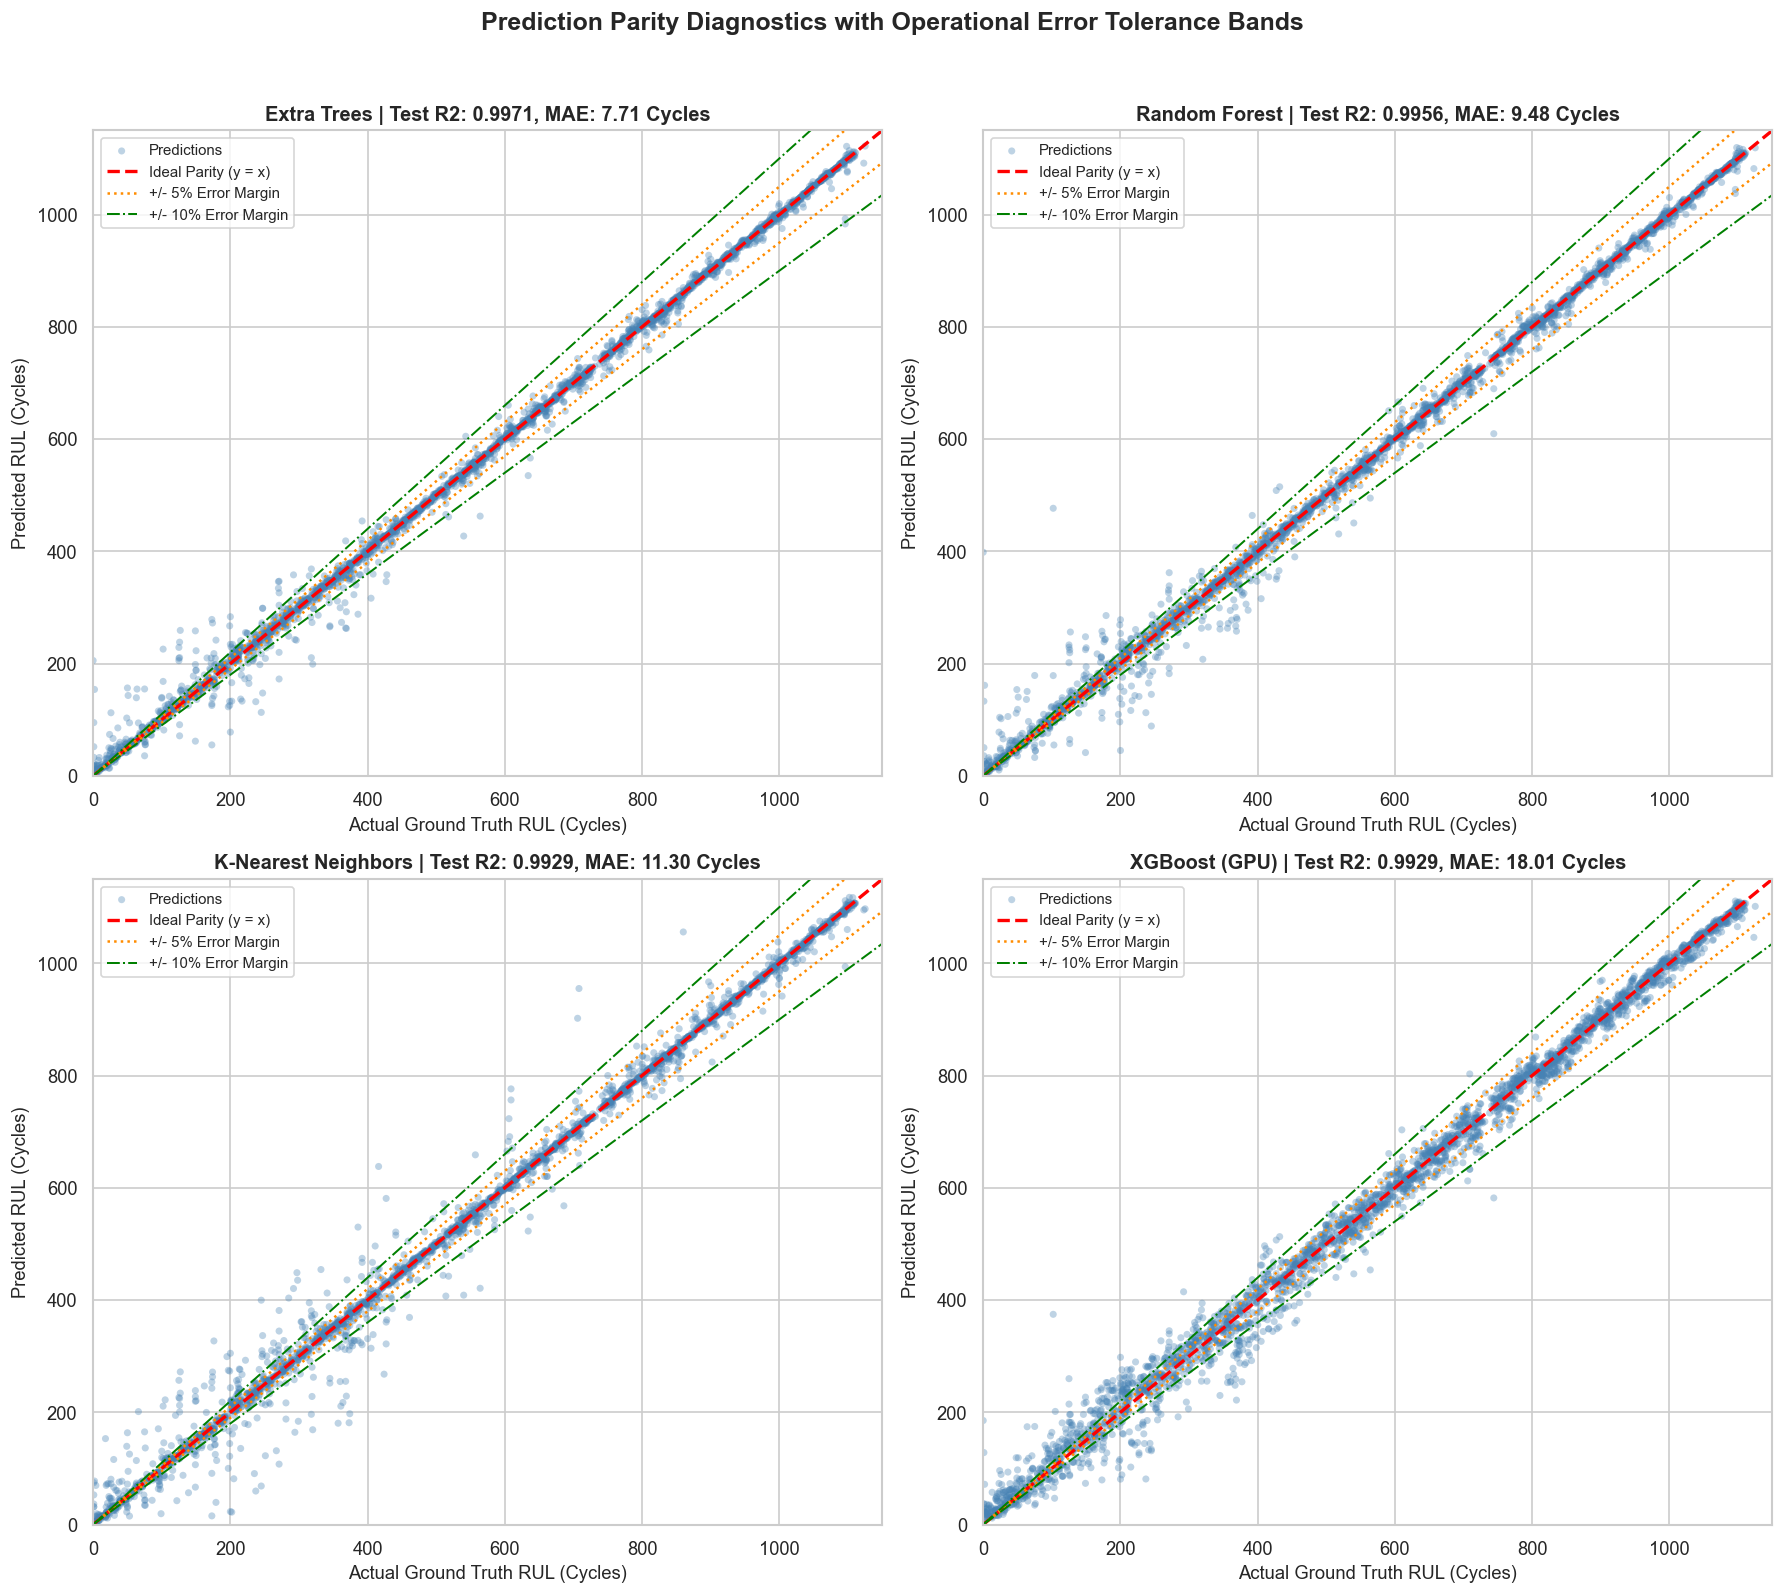

In [71]:
top_models = ["Extra Trees", "Random Forest", "K-Nearest Neighbors", "XGBoost (GPU)"]

fig, axes = plt.subplots(2, 2, figsize=(15, 13))
axes = axes.flatten()

for idx, m_name in enumerate(top_models):
    preds = optimized_test_preds[m_name]
    ax = axes[idx]
    
    ax.scatter(y_test, preds, alpha=0.35, color="steelblue", s=18, edgecolors="none", label="Predictions")
    ax.plot([0, 1150], [0, 1150], color="red", linestyle="--", linewidth=2, label="Ideal Parity (y = x)")
    ax.plot([0, 1150], [0, 1150 * 1.05], color="darkorange", linestyle=":", linewidth=1.5, label="+/- 5% Error Margin")
    ax.plot([0, 1150], [0, 1150 * 0.95], color="darkorange", linestyle=":", linewidth=1.5)
    ax.plot([0, 1150], [0, 1150 * 1.10], color="green", linestyle="-.", linewidth=1.2, label="+/- 10% Error Margin")
    ax.plot([0, 1150], [0, 1150 * 0.90], color="green", linestyle="-.", linewidth=1.2)
    
    m_r2 = optimized_results_df.loc[optimized_results_df['Model'] == m_name, 'Test R2'].values[0]
    m_mae = optimized_results_df.loc[optimized_results_df['Model'] == m_name, 'Test MAE'].values[0]
    
    ax.set_title(f"{m_name} | Test R2: {m_r2:.4f}, MAE: {m_mae:.2f} Cycles", fontweight="bold", fontsize=12)
    ax.set_xlabel("Actual Ground Truth RUL (Cycles)")
    ax.set_ylabel("Predicted RUL (Cycles)")
    ax.set_xlim(0, 1150)
    ax.set_ylim(0, 1150)
    ax.legend(loc="upper left", fontsize=9)

plt.suptitle("Prediction Parity Diagnostics with Operational Error Tolerance Bands", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Ensemble Feature Importance Rankings Across Tree and Boosting Models

Side-by-side bar plots comparing feature rankings across Extra Trees, Random Forest, XGBoost (GPU), and LightGBM.

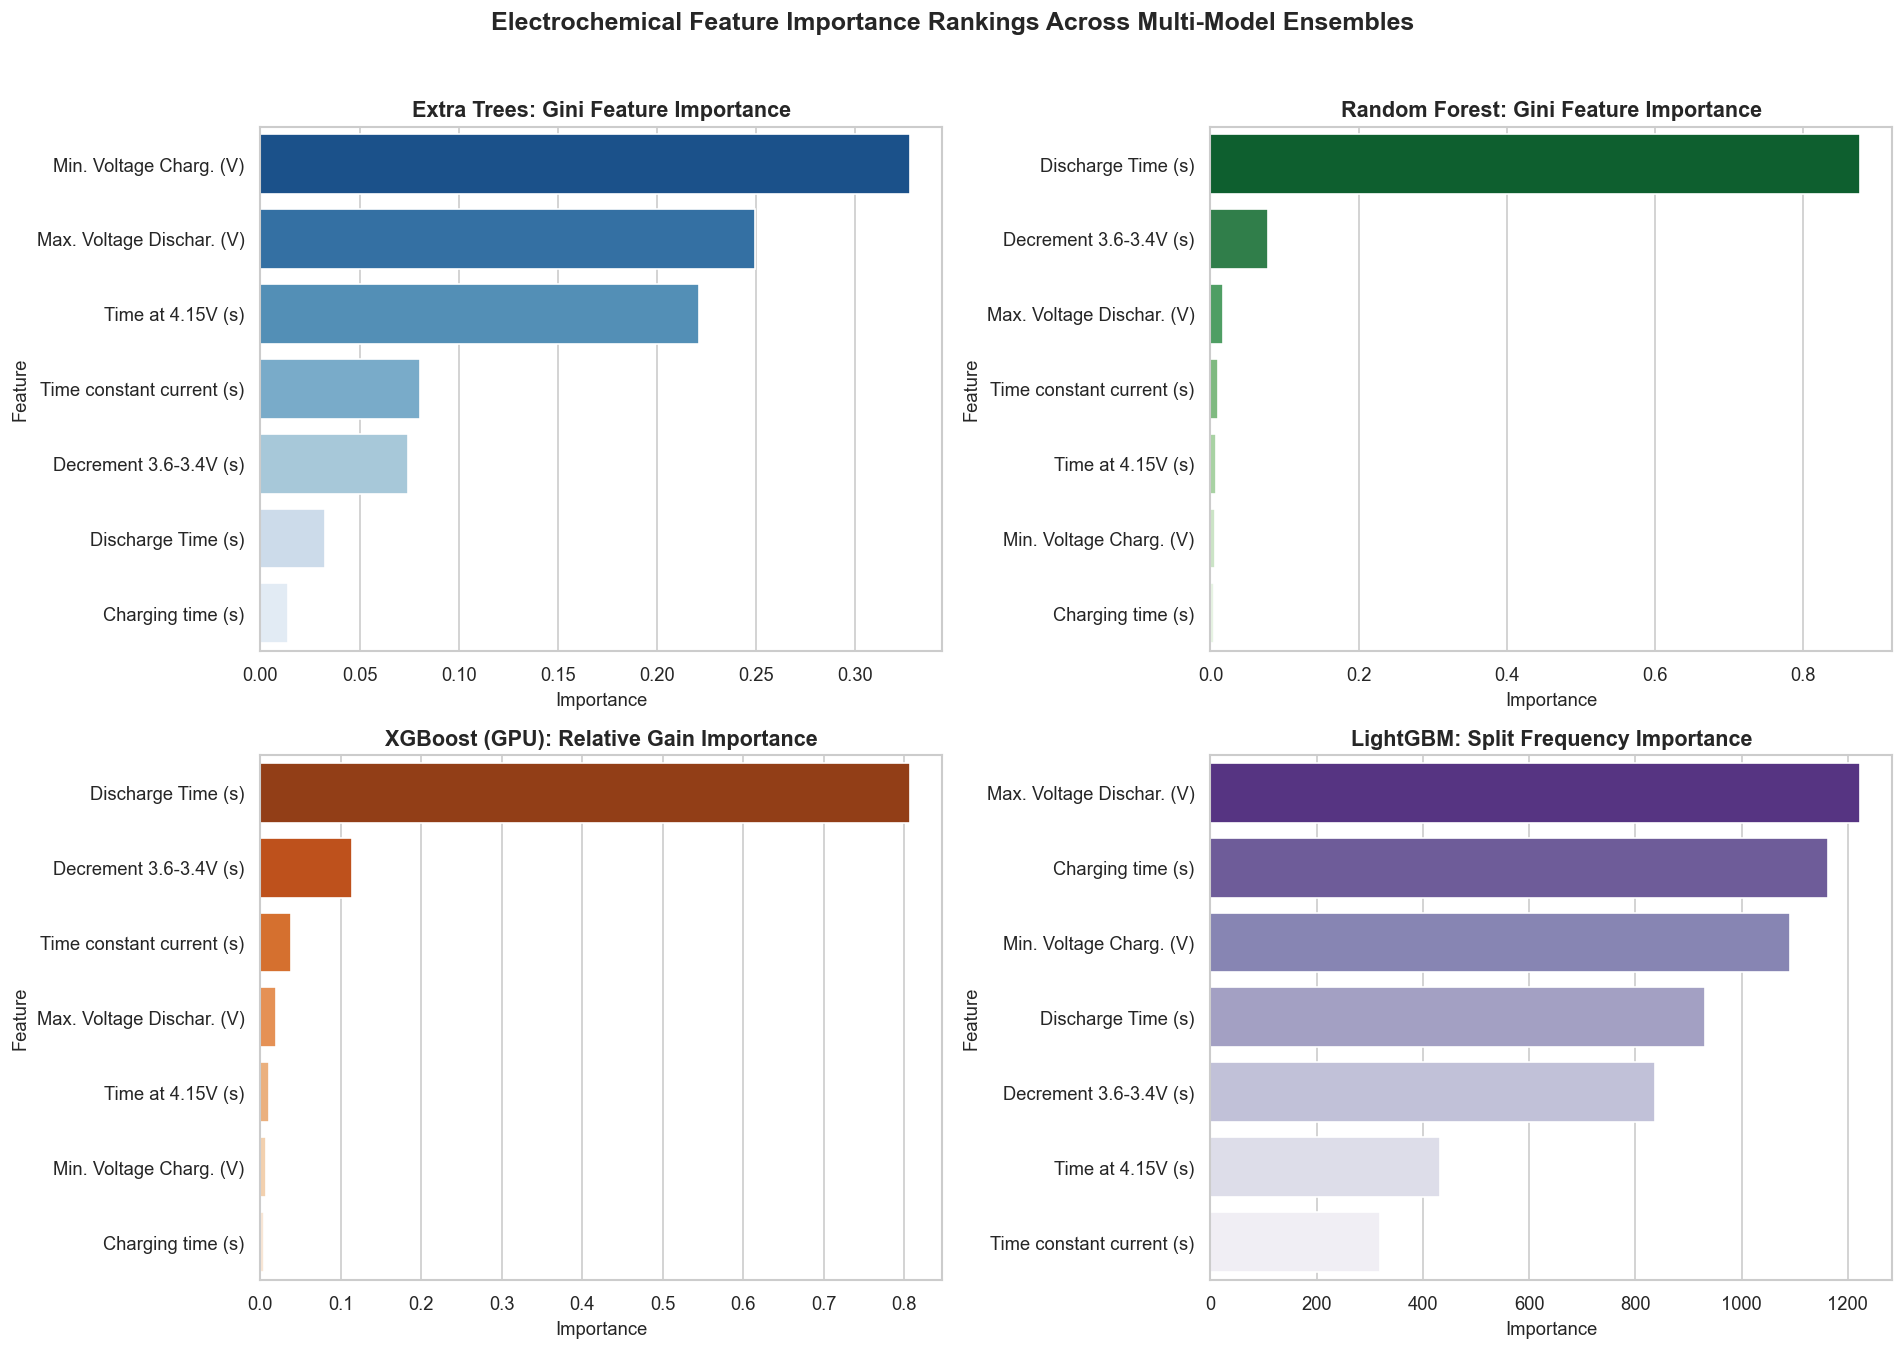

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
feature_names = X.columns

# 1. Extra Trees
et_importances = optimized_models["Extra Trees"].named_steps["model"].feature_importances_
et_df = pd.DataFrame({"Feature": feature_names, "Importance": et_importances}).sort_values(by="Importance", ascending=False)
sns.barplot(data=et_df, x="Importance", y="Feature", palette="Blues_r", ax=axes[0, 0])
axes[0, 0].set_title("Extra Trees: Gini Feature Importance", fontweight="bold")

# 2. Random Forest
rf_importances = optimized_models["Random Forest"].named_steps["model"].feature_importances_
rf_df = pd.DataFrame({"Feature": feature_names, "Importance": rf_importances}).sort_values(by="Importance", ascending=False)
sns.barplot(data=rf_df, x="Importance", y="Feature", palette="Greens_r", ax=axes[0, 1])
axes[0, 1].set_title("Random Forest: Gini Feature Importance", fontweight="bold")

# 3. XGBoost
xgb_importances = optimized_models["XGBoost (GPU)"].named_steps["model"].feature_importances_
xgb_df = pd.DataFrame({"Feature": feature_names, "Importance": xgb_importances}).sort_values(by="Importance", ascending=False)
sns.barplot(data=xgb_df, x="Importance", y="Feature", palette="Oranges_r", ax=axes[1, 0])
axes[1, 0].set_title("XGBoost (GPU): Relative Gain Importance", fontweight="bold")

# 4. LightGBM
lgbm_importances = optimized_models["LightGBM"].named_steps["model"].feature_importances_
lgbm_df = pd.DataFrame({"Feature": feature_names, "Importance": lgbm_importances}).sort_values(by="Importance", ascending=False)
sns.barplot(data=lgbm_df, x="Importance", y="Feature", palette="Purples_r", ax=axes[1, 1])
axes[1, 1].set_title("LightGBM: Split Frequency Importance", fontweight="bold")

plt.suptitle("Electrochemical Feature Importance Rankings Across Multi-Model Ensembles", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()